In [3]:
# Customer Churn Analysis

## Project Overview

#This project analyzes customer churn to understand customer retention, churn behavior, revenue at risk, and factors associated with customer attrition.

#Using Python, Pandas, NumPy, Matplotlib, Seaborn, and statistical analysis, the project covers data loading, exploratory data analysis (EDA), data cleaning, feature engineering, and visualization.

#The analysis combines customer, subscription, and customer support data to identify key churn patterns and generate actionable business insights. The results are further used for SQL analysis and Power BI dashboard development.



In [105]:
# Import Libraries

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [38]:
## data import
conn = sqlite3.connect(
    "data/customer_churn_large.db"
)

In [40]:
tables=pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)
print(tables)


              name
0      db_customer
1  db_subscription
2       db_support


In [41]:
for table_name  in tables['name']:
    df=pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"]=df
    print(f"the dataframe:df_{table_name}")
conn.close()    
    
    
    
    

the dataframe:df_db_customer
the dataframe:df_db_subscription
the dataframe:df_db_support


In [42]:
# data Understanding

In [43]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,drama,None


In [44]:
df_db_customer.info()


<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  1500 non-null   str   
 1   name        1500 non-null   str   
 2   country     1500 non-null   str   
 3   state       1500 non-null   str   
 4   gender      1500 non-null   str   
 5   dob         1500 non-null   str   
 6   interests   327 non-null    str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 93.9+ KB


In [45]:
# EDA/ Data Cleaning
## Customer Data Cleaning

#The customer dataset was cleaned by:
#- Renaming columns for clarity
#- Removing unnecessary columns
#- Converting date fields to datetime format
#- Standardizing categorical values
#- Handling missing country values

In [46]:
#a.rename col-name to custname
df_db_customer.rename(columns={'name':'customer_name'},inplace=True)
df_db_customer


,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,drama,None
...,...,...,...,...,...,...,...,...
1495,1498-OAUAO,Mohan,Nepal,Kathmandu,Female,1981-06-26,NaN,None
1496,1499-MXBWP,Ananya,India,Nagaland,Male,1968-07-01,NaN,None
1497,1500-UBLLG,Sneha,India,Uttar Pradesh,Female,1992-03-08,NaN,None
1498,1501-WTKMS,Sahil,India,Nagaland,Female,1966-01-22,food,None


In [47]:
#b.drop columns- interest and pincode
df_db_customer.drop(columns=['interests','pincode'],inplace=True)


In [48]:
#c.change data type-dob
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

In [49]:
#d.gender fixed-data standardization

#df_db_customer['gender'].unique()
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})


In [50]:
#e.fixed missing values-country
df_db_customer['country'].isna()
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [51]:
state_country_mapping=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

In [52]:
df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [53]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [54]:
# Subscription Data Cleaning
### Convert Date Columns
#Converted the subscription date columns to datetime format to enable accurate date-based analysis and calculations.

date_col=['subscription_start_date','cancellation_date','renewal_date']

df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)

In [55]:
### Create Churn Status
## Created a `churn_status` column to classify customers as **Active** or **Churned** based on 
## whether a cancellation date is available.

df_db_subscription['churn_status'] = np.where(
    df_db_subscription['cancellation_date'].isna(),
    'Active',
    'Churned'
)

In [56]:
df_db_subscription['churn_status'].value_counts()

churn_status
Active     1143
Churned     357
Name: count, dtype: int64

In [57]:
### Handle Missing Cancellation Reasons
##Replaced missing cancellation reasons with **"Not Applicable"** for customers who have not provided a cancellation reason.

df_db_subscription['cancellation_reason_clean'] = (
    df_db_subscription['cancellation_reason']
    .fillna('Not Applicable')
)

In [58]:
df_db_subscription.isnull().sum()

customerid                      0
subscription_start_date         0
subscription_type               0
renewal_date                    0
plan_type                       0
contract_type                   0
cancellation_date            1143
cancellation_reason          1143
monthly_charges                 0
cltv                            0
churn_score                     0
churn_status                    0
cancellation_reason_clean       0
dtype: int64

In [59]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28,N,60,None,service issue
1,0003-MKNFE,2024-08-28,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20,Y,20,None,NaN
3,0013-MHZWF,2025-03-18,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01,N,30,None,NaN


In [60]:
## Support Data Cleaning
### Remove Unnecessary Columns
### Removed the `col_1` and `comment` columns because they are not required for the customer churn analysis.

df_db_support.drop(columns=['col_1','comment'],inplace=True)

In [61]:
### Convert Complaint Date
## Converted the `complaint_date` column to datetime format to support accurate date-based analysis.

df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])

In [62]:
# feature Engineering & data analyst-> 

In [63]:
df_db_subscription.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_status,cancellation_reason_clean
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,Active,Not Applicable
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,Churned,Switched to competitor
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,Active,Not Applicable


In [64]:
# creating new col using existing col-churn flag
df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [65]:
# first fix support table duplicates then merge
df=(df_db_subscription
    .merge(df_db_customer,on='customerid',how='left')
    .merge(df_db_support, on='customerid', how='left'))

In [73]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [74]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [75]:
#  merge df
df=(df_db_subscription
    .merge(df_db_customer,on='customerid',how='left')
    .merge(df_db_support, on='customerid', how='left'))

In [76]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [77]:
# churn-Rate
churn_rate=df['churn_flag'].mean()*100
print("Churn Rate = ",round(churn_rate,2),"%")

Churn Rate =  23.8 %


In [78]:
#2.Rentention Rate
retention_rate=100-churn_rate
print("Retention Rate = ",round(retention_rate,2),"%")

Retention Rate =  76.2 %


In [79]:
#3.Churn by Plan type
churn_by_plan=df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_perc')
print(churn_by_plan)

  plan_type  churn_rate_perc
0     Basic            25.81
1   Premium            25.61
2  Standard            21.72


In [80]:
#multiple operation at once
## ### Revenue and Customer Count by State
# Grouped customers by state to calculate the **total revenue generated** and **total number of customers** in each state.

churn_by_state=df.groupby('state').agg(total_revenue=('monthly_charges','sum'),total_users=('customerid','count'))

In [81]:
### Revenue and Customer Count by Subscription
## Grouped customers by state to calculate the **total revenue generated** and **total number of customers** in each subscription.

churn_by_subscription=df.groupby('subscription_type').agg(total_revenue=('monthly_charges','sum'),total_users=('customerid','count'))

In [82]:
churn_by_subscription

,total_revenue,total_users
subscription_type,,
Organic,10465.19,681
Paid,7265.51,449
Refferal,5808.30,370


In [83]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_status', 'cancellation_reason_clean', 'churn_flag',
       'customer_name', 'country', 'state', 'gender', 'dob', 'complaint_date',
       'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [84]:
#5.Average revenue per user
arpu=df['monthly_charges'].mean()
print("ARPU =",round(arpu,2))

ARPU = 15.69


In [85]:
#Average customer Tenure
#6.count of days users has used our service : cancellation date else current date
today=pd.Timestamp.now()
df['tenure_days']=np.where(
    df['cancellation_date'].notna(),(df['cancellation_date']-df['subscription_start_date']).dt.days,(today-df['subscription_start_date']).dt.days
)
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,2003.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,1388.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,2678.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,419.0


In [86]:
avg_tenure=df['tenure_days'].mean()
print("Avg Tenure Days",round(avg_tenure),0)

Avg Tenure Days 1213 0


In [87]:
#7.Revenue at risk-revenue lost from churned users
revenue_at_risk=df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("Revenue at Risk (Rs.K)=",revenue_at_risk)

Revenue at Risk (Rs.K)= 5645.43


In [88]:
# 8.Esclation Rate
escalation_rate=(df['escalations']=='Y').mean()*100
print("Esclation Rate =",round(escalation_rate,2),'%')

Esclation Rate = 13.13 %


In [89]:
#9.Avg complaint per user
avg_complaints=df['complaint_count'].sum()/df['customerid'].nunique()
print("Avg Complaint per user=",round(avg_complaints,2))


Avg Complaint per user= 0.52


In [90]:
# Analyze the relationship between escalations and customer churn
df['escalations']=np.where(df['escalations']=='Y', 1, 0) # encoding str to int type
corr_df=df[['escalations','churn_flag']].dropna()
correlation=corr_df['escalations'].corr(df['churn_flag'])
print("Correlation B/w escalation vs churn is=",round(correlation,2))

Correlation B/w escalation vs churn is= 0.63


In [91]:
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2003.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1388.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2678.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1498-OAUAO,2020-12-18,Refferal,2021-12-18,Standard,Monthly,NaT,NaN,16.99,3476,...,Mohan,Nepal,Kathmandu,Female,1981-06-26,NaT,0,NaN,NaN,2090.0
1496,1499-MXBWP,2025-01-20,Paid,2026-01-20,Basic,Monthly,NaT,NaN,7.99,278,...,Ananya,India,Nagaland,Male,1968-07-01,NaT,0,NaN,NaN,596.0
1497,1500-UBLLG,2022-03-26,Refferal,2023-03-26,Standard,Monthly,NaT,NaN,13.99,1660,...,Sneha,India,Uttar Pradesh,Female,1992-03-08,NaT,0,NaN,NaN,1627.0
1498,1501-WTKMS,2022-07-21,Organic,2023-07-21,Basic,Monthly,NaT,NaN,7.99,733,...,Sahil,India,Nagaland,Female,1966-01-22,NaT,0,NaN,NaN,1510.0


In [92]:
#11.churn risk- create a col using existing col
conditions=[
    (df['churn_score']<50),
    (df['churn_score']>=50)&(df['churn_score']<70),
    (df['churn_score']>=70)
]

choices=['low','med','high']


df['churn_risk']=np.select(conditions,choices,default='Unknown')

In [93]:
df[['churn_risk','churn_score']].tail()

,churn_risk,churn_score
1495,low,32
1496,med,61
1497,med,66
1498,low,26
1499,low,14


In [94]:
# data visualisation using matploblib
df_visual=df.copy()

In [95]:
# monthly churn trend(time series KPI)
df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M')
churn_plot=df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()

In [100]:
churn_plot

cancellation_month
2019-05     2
2019-07     1
2019-08     3
2019-12     1
2020-01     3
           ..
2025-10    12
2025-11     3
2025-12     9
2026-01    16
2026-02    12
Freq: M, Length: 77, dtype: int64

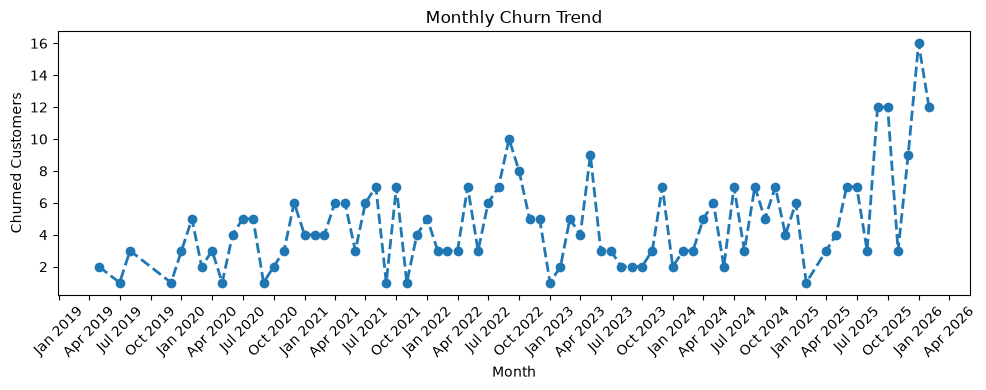

In [102]:
### Data Visualisation
plt.figure(figsize=(10, 4))

plt.plot(
    churn_plot.index.to_timestamp(),
    churn_plot.values,
    marker='o',
    linestyle='dashed',
    linewidth=2,
    markersize=6
)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

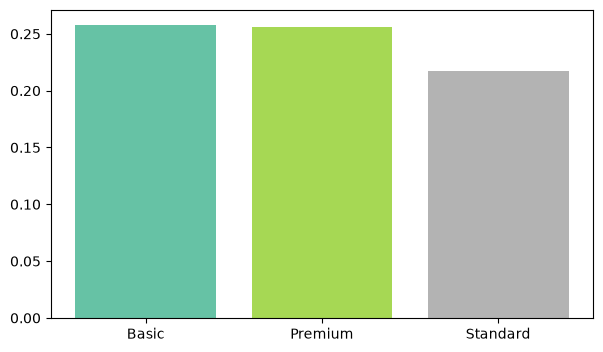

In [103]:
# churn by plan type
churn_plan=df_visual.groupby('plan_type')['churn_flag'].mean() 
#color=['yellow','purple','blue']
#for random colors
color=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index,churn_plan.values,color=color)
plt.show()


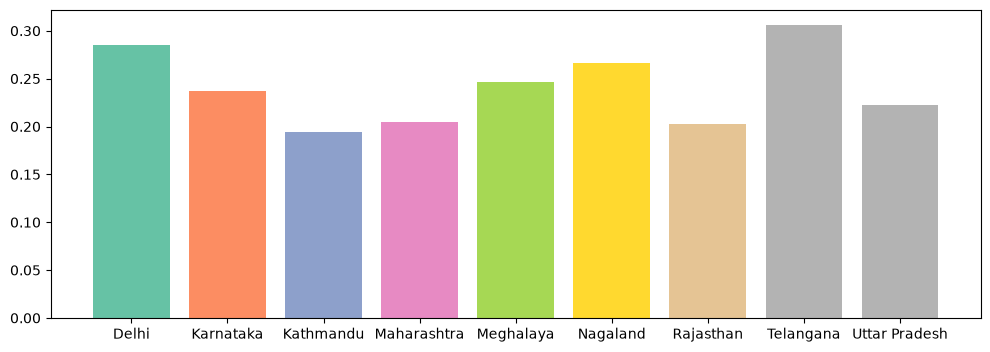

In [104]:
# churn by States 
churn_plan=df_visual.groupby('state')['churn_flag'].mean() 
#color=['yellow','purple','blue']
#for random colors
color=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(12,4))
plt.bar(churn_plan.index,churn_plan.values,color=color)
plt.show()


In [96]:
# encoding - convert str to numeric so that we can find corr btw features
df_visual[['plan_type', 'contract_type','churn_score',
       'churn_flag', 'escalations','churn_risk']].head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,Standard,Annual,12,0,0,low
1,Premium,Annual,91,1,1,high
2,Basic,Monthly,34,0,0,low
3,Premium,Annual,8,0,0,low
4,Standard,Monthly,88,1,1,high


In [98]:
#correct method of encoding-assigned bsed on priority-> 2 most priority given according to alphabet
df_encoded=df[['plan_type', 'contract_type','churn_score',
       'churn_flag', 'escalations','churn_risk']]
order_mapping={
    'plan_type':['Basic','Standard','Premium'],
    'contract_type':['Monthly','Annual'],
    'churn_risk':['low','med','high']
}
for col,order in order_mapping.items():
    df_encoded[col]=pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes

<Axes: >

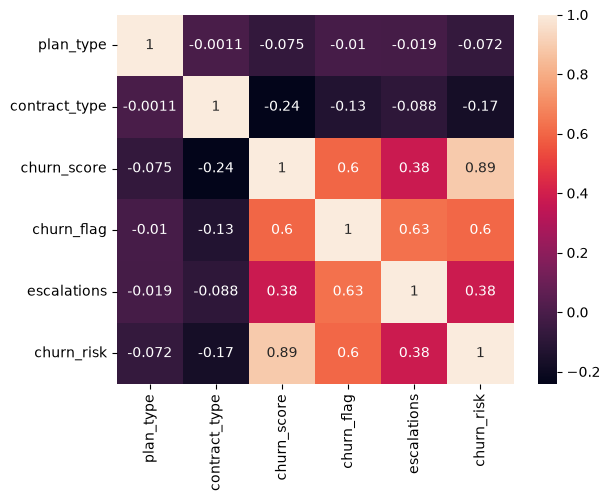

In [100]:
#heatmap (correlation matrix)-> only take numeric values

sns.heatmap(df_encoded.corr(),annot=True)

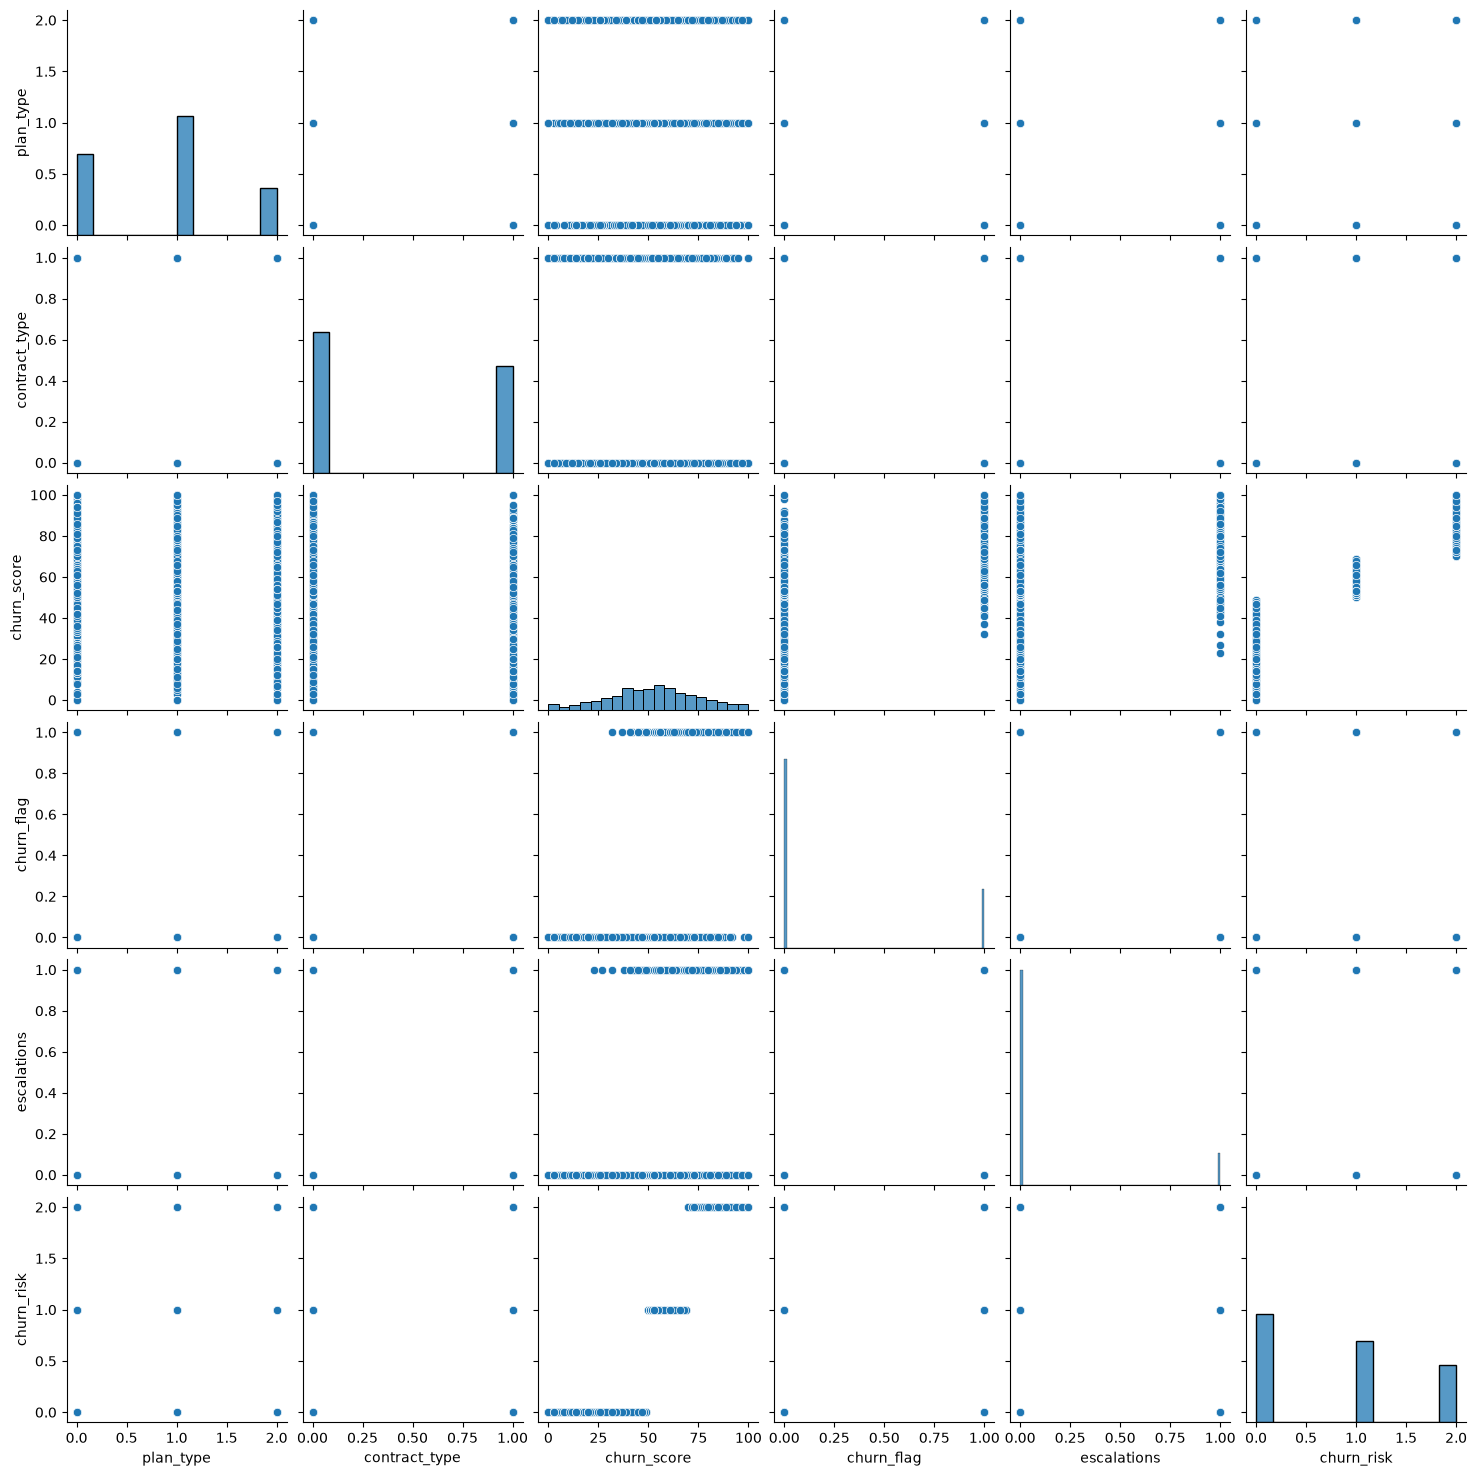

In [101]:
#pairplot-relationship in a dataset
sns.pairplot(df_encoded)

In [109]:
import pymysql
from sqlalchemy import create_engine

password = input("Enter MySQL password: ")

connection = pymysql.connect(
    host="localhost",
    port=3306,
    user="root",
    password=password,
    database="customer_behavior"
)

engine = create_engine(
    "mysql+pymysql://",
    creator=lambda: connection
)

print("SQLAlchemy engine created!")

Enter MySQL password:  290707@aZ


SQLAlchemy engine created!


In [111]:
df.to_sql(
    "customer_churn",
    engine,
    if_exists="replace",
    index=False
)

1500

In [112]:
pd.read_sql(
    "SELECT * FROM customer_churn LIMIT 5;",
    engine
)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1997.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1382.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2672.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high


In [113]:
# Statistical Analysis

Chi-square: 24.845376800896908
p-value: 6.211784547191934e-07


In [113]:
# Is customer churn associated with contract type?
from scipy.stats import chi2_contingency
import pandas as pd

table = pd.crosstab(
    df['contract_type'],
    df['churn_status']
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)
# Reject null hypothesis

Chi-square: 24.845376800896908
p-value: 6.211784547191934e-07


In [114]:
# Does churn depend on the customer's plan type?
table = pd.crosstab(
    df['plan_type'],
    df['churn_status']
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 3.3494087438890086
p-value: 0.18736356122063022


In [115]:
# Do churned and active customers have different monthly charges?
from scipy.stats import mannwhitneyu

churned = df.loc[
    df['churn_status'] == 'Churned',
    'monthly_charges'
]

active = df.loc[
    df['churn_status'] == 'Active',
    'monthly_charges'
]

stat, p = mannwhitneyu(
    churned,
    active,
    alternative='two-sided'
)

print("U statistic:", stat)
print("p-value:", p)

U statistic: 200026.0
p-value: 0.5743127449261292


In [116]:
# Does churn score differ between churned and active customers?
churned = df.loc[
    df['churn_status'] == 'Churned',
    'churn_score'
]

active = df.loc[
    df['churn_status'] == 'Active',
    'churn_score'
]

stat, p = mannwhitneyu(
    churned,
    active,
    alternative='two-sided'
)

print("U statistic:", stat)
print("p-value:", p)

U statistic: 370571.0
p-value: 3.1769921600655784e-120


In [106]:
## Key Business Insight

#* **Customer churn:** The analysis shows a **23.8% churn rate**, with 357 out of 1,500 customers classified as churned, while 76.2% of customers remain active.

#* **Revenue at risk:** Churned customers represent approximately **Rs. 5,645.43K in monthly revenue at risk**, highlighting the financial impact of customer attrition.

#* **Customer support and churn:** The analysis found a **0.63 correlation between escalations and churn**, indicating a notable relationship between customer escalations and churn behavior.

#* **Customer support activity:** Customers generated an average of **0.52 complaints per user**, while the overall escalation rate was **13.13%**.

#* **Customer value:** The calculated **Average Revenue Per User (ARPU) is 15.69**, providing a useful measure of average monthly revenue generated per customer.

#* **Churn risk:** The analysis uses existing churn scores to segment customers into **Low, Medium, and High churn-risk groups**, which can help identify customers who may require targeted retention efforts.


In [5]:
## Conclusion
##The customer churn analysis provides a clear view of customer retention, revenue exposure, and factors associated with churn. With a **23.8% churn rate**, customer attrition represents a significant business concern, particularly because churned customers contribute to measurable revenue at risk.

#The analysis also shows a notable relationship between **customer escalations and churn**, suggesting that improving customer support and addressing issues proactively may help reduce customer attrition. Churn-risk segmentation can further support targeted retention strategies by helping the business identify customers who may require additional attention.

#Overall, the analysis combines **Python-based data cleaning and analysis, SQL, statistical analysis, and visualization** to turn customer data into actionable business insights.
